In [84]:
#importing libraries
# site scrapping - https://jiji.ng/api_web/v1/listing?slug=cars&page=1&webp=True
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv("jiji_car_dataset.csv")

In [85]:
def extract_make_model_year(title):
    clean_title = re.sub(r"^New\s+", "", title, flags=re.IGNORECASE)
    pattern = r"(?P<make>\b[a-zA-Z\-]+)\s+(?P<model>[A-Za-z0-9\-]+(?:\s[A-Za-z0-9\-]+)?)?.*?(?P<year>\d{4})(?!\d)"
    match = re.search(pattern, clean_title)
    if match:
        return match.group("make"), match.group("model"), match.group("year")
    return None, None, None

In [86]:
df[["make", "model", "year"]] = df["title"].apply(
    lambda x: pd.Series(extract_make_model_year(x))
)

In [87]:
def extract_condition(condition):
    condition_lower = condition.lower()
    if "foreign used" in condition_lower:
        return "foreign used"
    elif "local used" in condition_lower:
        return "local used"
    elif "brand new" in condition_lower:
        return "brand new"
    else:
        return None

In [88]:
def extract_transmission(transmission):
    transmission_lower = transmission.lower()
    if "automatic" in transmission_lower:
        return "automatic"
    elif "manual" in transmission_lower:
        return "manual"
    else:
        return None

In [89]:
#communicatting with API
def fetch_data(page):
    url = "https://jiji.ng/api_web/v1/listing"
    params = {
        "slug": "cars",
        "page": page,
        "webp": True
    }

    headers = {
        "User_Agent": "Mozilla/5.0"
    }
    try:
        response = requests.get(url, headers=headers, params=params)
        data = response.json()
    except requests.RequestException:
        print(f"[Page] {page}, Request error")
        return []
    except ValueError:
        print(f"[Page] {page}, Decode error")

    adverts = data.get("adverts_list", {}).get("adverts", [])
    if not isinstance(adverts, list):
        print(f"A error occured, Expected list but got {type(adverts)}")
        return []

    return adverts

In [90]:
def get_attr_value(attrs, key_name):
    for attr in attrs:
        if attr.get("name", "").lower() == key_name.lower():
            return attr.get("value", "").strip()
    return None

In [91]:
# #control function - carries all functionality of the code
# def main():
#     all_ads = []
#     for page in range(1, 101):
#         ads = fetch_data(page)
#         print(f"Page {page}. {len(ads)} ads found.")

#         for ad in ads:
#             if isinstance(ad, dict):
#                 attrs = ad.get("attrs", [])
#                 title = ad.get("title", "")
#                 condition_ = get_attr_value(attrs, "condition")
#                 transmission_ = get_attr_value(attrs, "transmission")
#                 condition = extract_condition(condition_)
#                 transmission = extract_transmission(transmission_)
#                 make, model, year = extract_make_model_year(title)
#                 price = ad.get("price_title", "")

#                 if price:
#                     all_ads.append({
#                         "title": title,
#                         "make": make,
#                         "model": model,
#                         "year": year,
#                         "condition": condition, 
#                         "transmission": transmission,
#                         "price": price
#                     })
#     if all_ads:
#         df = pd.DataFrame(all_ads)
#         df.to_csv("new_jiji_car_dataset.csv", index=False)
#         print("Successfully extracted car dataset from Jiji.")
#     else:
#         print("Ops! Nothing to extract.")

# main()

In [92]:
df.to_csv("new_jiji_car_dataset.csv", index=False)

**DATA CLEANING**

In [93]:
df = pd.read_csv("new_jiji_car_dataset.csv")
df.isnull().sum()

title            0
make            19
model           19
year            19
condition        0
transmission     8
price            0
dtype: int64

In [94]:
df.head()

,title,make,model,year,condition,transmission,price
0,Lexus ES 330 2006,Lexus,ES 330,2006.0,local used,automatic,"₦ 6,500,000"
1,Lexus RX 350 F Sport AWD 2018 Black,Lexus,RX 350,2018.0,local used,automatic,"₦ 31,000,000"
2,New Zeekr 9X 2026 Black,Zeekr,9X,2026.0,brand new,automatic,"₦ 220,000,000"
3,Lexus RX 350 F Sport AWD 2016 Red,Lexus,RX 350,2016.0,foreign used,automatic,"₦ 58,500,000"
4,Lexus RX 350 FWD 2012 Gray,Lexus,RX 350,2012.0,foreign used,automatic,"₦ 20,500,000"


In [95]:
df = df.dropna()
df.isnull().sum()

title           0
make            0
model           0
year            0
condition       0
transmission    0
price           0
dtype: int64

In [96]:
df.info()

<class 'pandas.DataFrame'>
Index: 1971 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1971 non-null   str    
 1   make          1971 non-null   str    
 2   model         1971 non-null   str    
 3   year          1971 non-null   float64
 4   condition     1971 non-null   str    
 5   transmission  1971 non-null   str    
 6   price         1971 non-null   str    
dtypes: float64(1), str(6)
memory usage: 280.1 KB


In [97]:
df["price"] = (
    df["price"]
    .astype(str)
    .replace('[₦,]', "", regex=True)
    .astype(float)
)
df["price"].head()

0      6500000.0
1     31000000.0
2    220000000.0
3     58500000.0
4     20500000.0
Name: price, dtype: float64

In [98]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

detect_outlier = (
    (df["price"] < lower_bound) | (df["price"] > upper_bound)
)
print(detect_outlier.sum())
# print(df.loc[detect_outlier, "price"])  

198


In [99]:
df.reset_index()

,index,title,make,model,year,condition,transmission,price
0,0,Lexus ES 330 2006,Lexus,ES 330,2006.0,local used,automatic,6500000.0
1,1,Lexus RX 350 F Sport AWD 2018 Black,Lexus,RX 350,2018.0,local used,automatic,31000000.0
2,2,New Zeekr 9X 2026 Black,Zeekr,9X,2026.0,brand new,automatic,220000000.0
3,3,Lexus RX 350 F Sport AWD 2016 Red,Lexus,RX 350,2016.0,foreign used,automatic,58500000.0
4,4,Lexus RX 350 FWD 2012 Gray,Lexus,RX 350,2012.0,foreign used,automatic,20500000.0
...,...,...,...,...,...,...,...,...
1966,1993,Toyota Camry LE (2.5L 4cyl 8A) 2019 Silver,Toyota,Camry LE,2019.0,foreign used,automatic,21500000.0
1967,1994,Toyota Camry L FWD (2.5L 4cyl 8AM) 2018 Silver,Toyota,Camry L,2018.0,foreign used,automatic,27800000.0
1968,1995,Mercedes-Benz B-Class 2009 Gray,Mercedes-Benz,B-Class,2009.0,foreign used,automatic,7000000.0
1969,1996,Lexus ES 350 2010 Silver,Lexus,ES 350,2010.0,foreign used,automatic,10800000.0


In [100]:
print(df["price"].min())
print(df["price"].max())

1850000.0
567000000.0


In [101]:
df["year"].unique()

array([2006., 2018., 2026., 2016., 2012., 2025., 2005., 2003., 2014.,
       2008., 2011., 2022., 2023., 2024., 2020., 2013., 2009., 2015.,
       2019., 2004., 2007., 2017., 2010., 2000., 2021., 2001., 1998.,
       2002., 1999.])

In [102]:
df["make"] = (df["make"].replace("-", " ", regex=True))
df["condition"] = (df["condition"].str.title())
df["transmission"] = (df["transmission"].str.title())
df["year"] = (
    df["year"]
    .astype(float)
    .astype(int)
)
df.head()

,title,make,model,year,condition,transmission,price
0,Lexus ES 330 2006,Lexus,ES 330,2006,Local Used,Automatic,6500000.0
1,Lexus RX 350 F Sport AWD 2018 Black,Lexus,RX 350,2018,Local Used,Automatic,31000000.0
2,New Zeekr 9X 2026 Black,Zeekr,9X,2026,Brand New,Automatic,220000000.0
3,Lexus RX 350 F Sport AWD 2016 Red,Lexus,RX 350,2016,Foreign Used,Automatic,58500000.0
4,Lexus RX 350 FWD 2012 Gray,Lexus,RX 350,2012,Foreign Used,Automatic,20500000.0


In [103]:
df.info()

<class 'pandas.DataFrame'>
Index: 1971 entries, 0 to 1997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1971 non-null   str    
 1   make          1971 non-null   str    
 2   model         1971 non-null   str    
 3   year          1971 non-null   int64  
 4   condition     1971 non-null   str    
 5   transmission  1971 non-null   str    
 6   price         1971 non-null   float64
dtypes: float64(1), int64(1), str(5)
memory usage: 253.2 KB


In [104]:
df = df.to_csv("cleaned_jiji_car_dataset.csv", index=False)

**EDA - DATA ANALYSIS & VISUALIZATION**

In [105]:
#What are the most common car brands (make)? - Frequency count of each brand.
df = pd.read_csv("cleaned_jiji_car_dataset.csv")
df["make"].value_counts()

make
Toyota           814
Lexus            267
Honda            211
Mercedes Benz    208
Acura            184
Hyundai           73
BMW               36
Peugeot           30
Ford              24
Land              23
Kia               13
Pontiac           13
Nissan            13
Chevrolet         11
Mazda             10
Volkswagen        10
Mitsubishi         3
Dodge              3
GAC                3
Zeekr              2
Jaguar             2
Audi               2
Mini               2
Forthing           1
Changan            1
Leapmotor          1
Renault            1
Dongfeng           1
Jetour             1
Geely              1
Chrysler           1
Denza              1
Infiniti           1
Volvo              1
Bentley            1
Cadillac           1
Rover              1
Name: count, dtype: int64

In [106]:
df.groupby("make")["price"].mean().sort_values(ascending=False).map('{:,.0f}'.format)

make
Bentley          325,000,000
Zeekr            183,750,000
Denza            180,000,000
GAC               62,333,333
Geely             60,600,000
Leapmotor         49,000,000
Land              46,529,620
Cadillac          40,000,000
Forthing          36,000,000
Jetour            35,000,000
Dodge             32,000,000
Mercedes Benz     31,861,096
Dongfeng          27,500,000
Lexus             23,741,931
Toyota            19,216,152
Mini              18,250,000
Rover             17,500,000
Ford              16,982,812
Changan           16,500,000
Volvo             14,000,000
Volkswagen        13,270,000
BMW               13,012,194
Mazda             12,775,000
Acura             12,246,929
Hyundai           12,186,575
Mitsubishi        12,166,666
Chevrolet         12,120,028
Jaguar            12,000,000
Audi              11,200,000
Honda             10,735,638
Nissan             9,457,692
Chrysler           8,500,000
Pontiac            7,184,615
Kia                6,880,769
Peugeot  

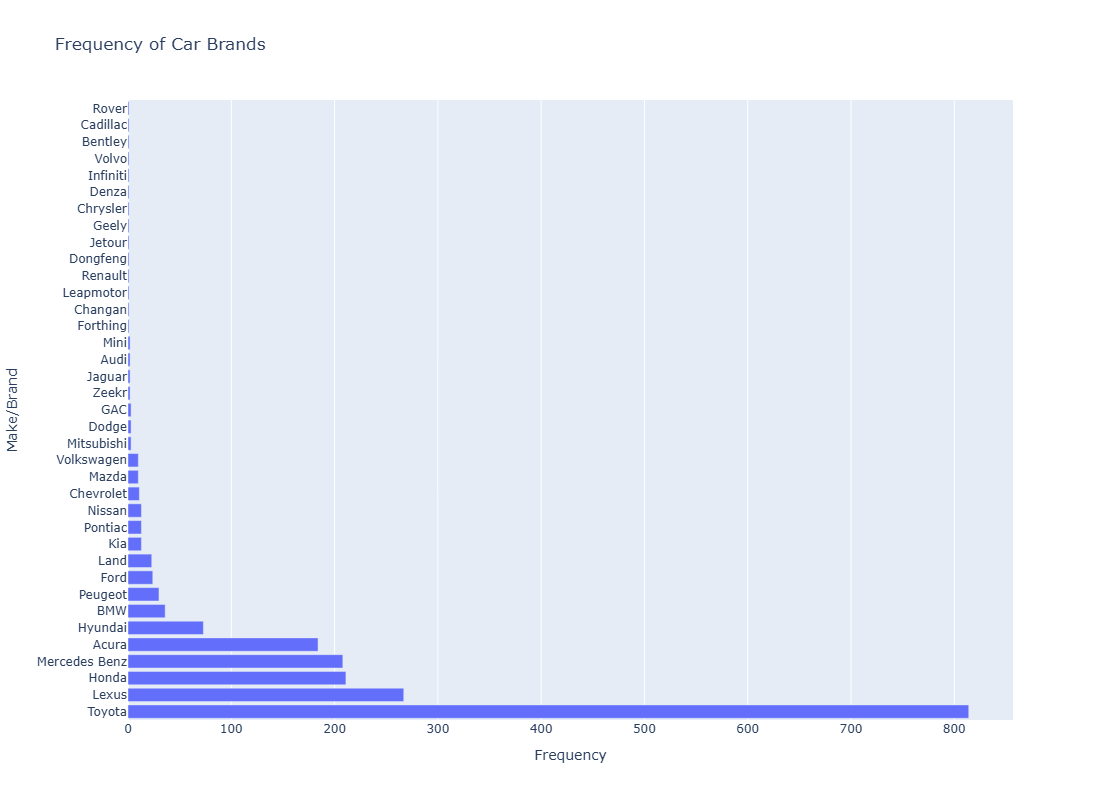

In [107]:
#Visualize with a bar chart
make_counts = df["make"].value_counts()
fig1 = px.bar(
    x = make_counts.values,
    y = make_counts.index,
    title = "Frequency of Car Brands"
)
fig1.update_layout(
    xaxis_title="Frequency",
    yaxis_title= "Make/Brand",
    height=800
)

fig1.show()

In [108]:
#most common models per brand
df.groupby("make")["model"].value_counts()

make        model         
Acura       MDX               81
            MDX Technology    35
            MDX Advance       28
            MDX SUV           16
            MDX w              6
                              ..
Volkswagen  Caddy              1
            E-Golf             1
            Beetle 2           1
Volvo       XC90 3             1
Zeekr       9X                 2
Name: count, Length: 332, dtype: int64

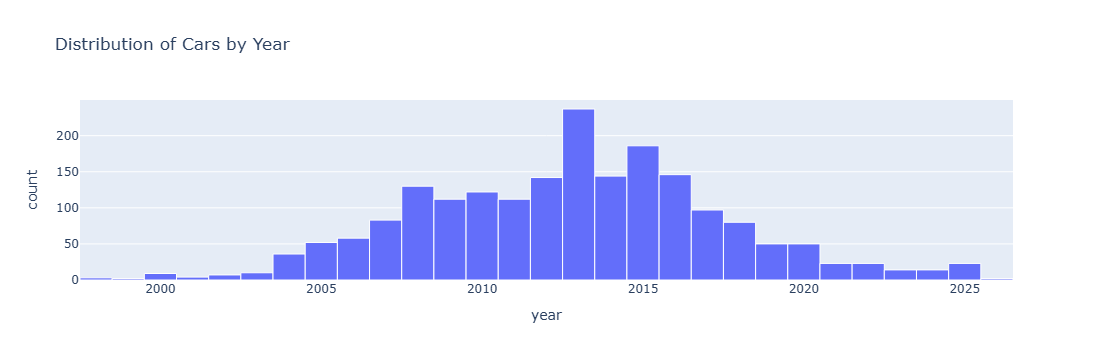

In [109]:
#Histogram of year shows age distribution of listed cars.
fig2 = px.histogram(
    df,
    x="year",
    title="Distribution of Cars by Year"
)
fig2.update_traces(
    marker_line_color="white",
    marker_line_width=1
)
fig2.show()

In [110]:
#Compare mean/median price by make and model.
# mean_make = df.groupby("make")["price"].mean()
# median_make = df.groupby("make")["price"].median()

# mean_model = df.groupby("model")["price"].mean()
# median_model = df.groupby("model")["price"].median()

# print("Mean price by make:", mean_make)
# print("Median price by make:", median_make)
# print("Mean price by model:", mean_model)
# print("Median price by model:", median_model)

df.groupby(['make', 'model'])['price'].agg(['mean', 'median']).sort_values(ascending=False, by="make").map('{:,.0f}'.format)

mean       median
make       model                                   
Zeekr      9X              183,750,000  183,750,000
Volvo      XC90 3           14,000,000   14,000,000
Volkswagen Beetle 2         15,500,000   15,500,000
           Caddy             8,300,000    8,300,000
           E-Golf           25,000,000   25,000,000
...                                ...          ...
Acura      MDX Technology   10,365,714   10,500,000
           MDX w            21,916,667   23,000,000
           RDX              13,000,000   13,000,000
           TL SH-AWD        12,500,000   12,500,000
           ZDX Base         16,491,667   17,250,000

[332 rows x 2 columns]

In [111]:
#Compare “Foreign Used” vs “Local Used” prices
df.groupby("condition")["price"].mean().map('{:,.0f}'.format)

condition
Brand New       154,614,286
Foreign Used     22,992,237
Local Used       10,034,111
Name: price, dtype: str

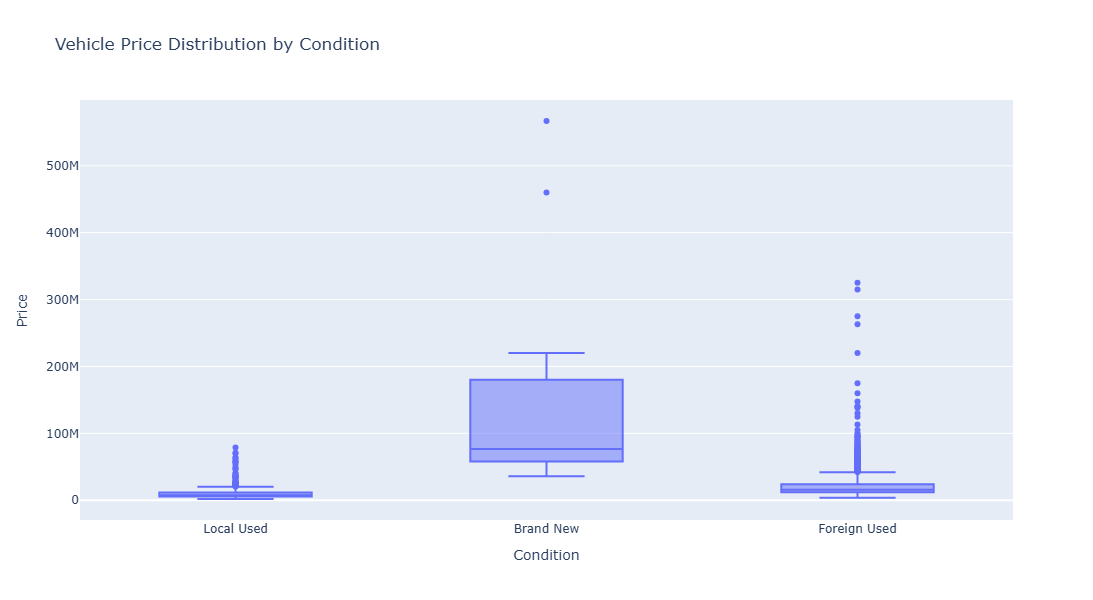

In [112]:
#Boxplot for visual insight
fig3 = px.box(
    df,
    x="condition",
    y="price",
    title="Vehicle Price Distribution by Condition",
    labels={
        "condition": "Condition",
        "price": "Price"
    }
)

fig3.update_layout(
    width=1000,
    height=600
)

fig3.show()

In [113]:
#Compare “Automatic” vs “Manual”.
df.groupby("transmission")["price"].mean().map('{:,.0f}'.format)

transmission
Automatic    19,570,105
Manual       12,093,478
Name: price, dtype: str

In [114]:
#Correlation coefficient between year and price.
df.groupby("year")["price"].mean().map('{:,.0f}'.format)

year
1998      3,433,333
1999      3,200,000
2000      4,911,111
2001      3,400,000
2002      4,028,571
2003      5,224,700
2004      4,707,669
2005      6,688,108
2006      6,732,931
2007      7,569,819
2008      8,047,385
2009      9,151,613
2010     10,407,459
2011     12,534,565
2012     13,772,782
2013     14,461,814
2014     16,050,582
2015     18,850,181
2016     21,557,840
2017     25,657,216
2018     32,178,529
2019     37,196,980
2020     41,613,625
2021     54,663,043
2022    104,098,845
2023    100,121,429
2024     77,264,286
2025     91,780,435
2026    183,750,000
Name: price, dtype: str

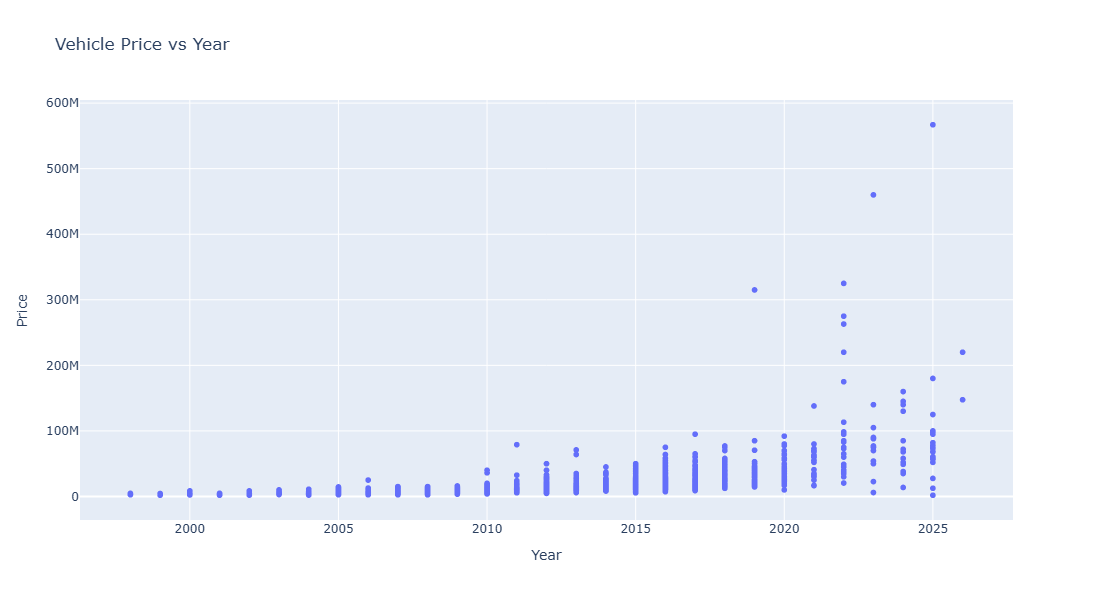

In [115]:
#Scatterplot of year vs price.
fig4 = px.scatter(
    df,
    x="year",
    y="price",
    title="Vehicle Price vs Year",
    labels={
        "year": "Year",
        "price": "Price"
    },
    width=800,
    height=600
)


fig4.show()